In [1]:
from IPython.display import clear_output
!pip install git+https://github.com/shijianjian/EfficientNet-PyTorch-3D
clear_output()

In [2]:
import os 
main_path = "/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification"
for files in os.listdir(main_path):
    print(files)

sample_submission.csv
train_labels.csv
test
train


In [3]:
import numpy as np
import pandas as pd
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-talk')
import torch
import glob
import random
import os

import os
import sys
import cv2
import torch
import random
import warnings
import torchvision
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import pydicom as pdcm
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = 12, 6 

/tmp/ipykernel_24/905196086.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-talk')


In [4]:
train_df = pd.read_csv("../input/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv")
train_df

,BraTS21ID,MGMT_value
0,0,1
1,2,1
2,3,0
3,5,1
4,6,1
...,...,...
580,1005,1
581,1007,1
582,1008,1
583,1009,0


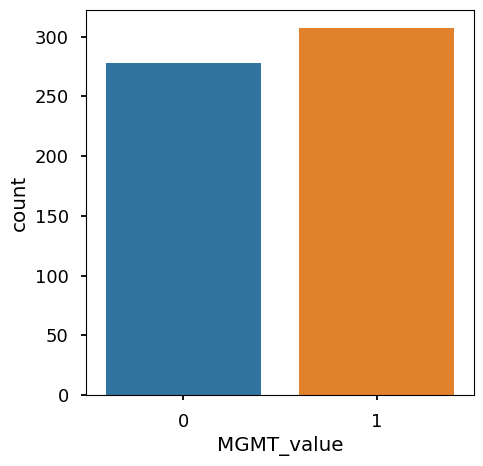

In [5]:
plt.figure(figsize=(5, 5))
sns.countplot(data=train_df, x="MGMT_value");


In [6]:
train_df = pd.read_csv(f"{main_path}/train_labels.csv")
test_df = pd.read_csv(f"{main_path}/sample_submission.csv")

for ids in [109, 123, 709]:
    train_df.drop(train_df[train_df["BraTS21ID"]==ids].index, inplace=True)   

In [7]:
mp_mri_type = ['FLAIR', 'T1w', 'T1wCE', 'T2w']

def build_df(dataframe, train=True):
    dir_type = ("train" if train else "test")
    for mp_type in mp_mri_type:
        count = [] 
        for ids in dataframe["BraTS21ID"]:
            fid = str(ids).zfill(5)
            file = os.listdir(f"{main_path}/{dir_type}/{fid}/{mp_type}")
            count.append(len(file))
        dataframe[mp_type] = count    
    return dataframe

train_df = build_df(train_df, train=True)
test_df = build_df(test_df, train=False)

train_df["CountImages"] = train_df["FLAIR"] + train_df["T1w"] + train_df["T2w"] + train_df["T1wCE"]
test_df["CountImages"] = test_df["FLAIR"] + test_df["T1w"] + test_df["T2w"] + test_df["T1wCE"]

In [8]:
train_df.describe()

,BraTS21ID,MGMT_value,FLAIR,T1w,T1wCE,T2w,CountImages
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,431.785223,0.525773,127.164948,132.522337,165.580756,171.432990,596.701031
std,251.249415,0.499765,101.333673,91.388893,81.362322,156.753097,318.457718
min,0.000000,0.000000,15.000000,19.000000,19.000000,19.000000,80.000000
25%,220.250000,0.000000,60.000000,32.000000,129.000000,64.000000,418.250000
50%,424.000000,1.000000,60.000000,180.000000,192.000000,64.000000,508.000000
75%,629.500000,1.000000,200.000000,192.000000,192.000000,376.000000,911.000000
max,1010.000000,1.000000,514.000000,400.000000,400.000000,472.000000,1372.000000


In [9]:
test_df.describe()

,BraTS21ID,MGMT_value,FLAIR,T1w,T1wCE,T2w,CountImages
count,87.000000,87.0,87.000000,87.000000,87.000000,87.000000,87.000000
mean,422.436782,0.5,124.321839,136.758621,165.264368,165.298851,591.643678
std,258.770110,0.0,99.369114,95.764363,80.330344,155.083932,313.018016
min,1.000000,0.5,19.000000,20.000000,23.000000,20.000000,92.000000
25%,186.000000,0.5,60.000000,32.000000,129.000000,62.000000,428.500000
50%,434.000000,0.5,64.000000,182.000000,192.000000,64.000000,508.000000
75%,623.500000,0.5,200.000000,192.000000,192.000000,352.000000,858.000000
max,1006.000000,0.5,412.000000,352.000000,352.000000,464.000000,1336.000000


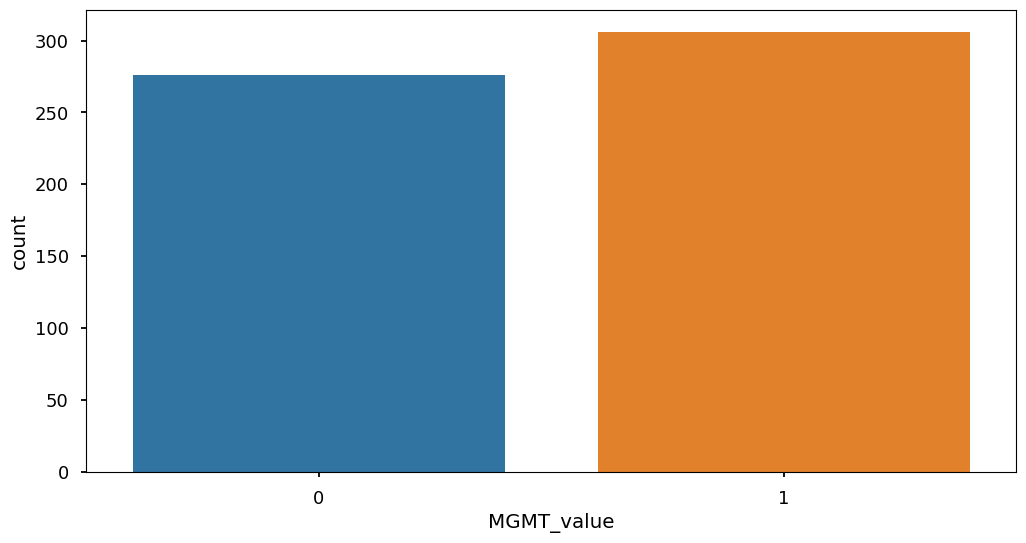

In [10]:
sns.countplot(x='MGMT_value', data=train_df)
plt.show()

In [11]:
IMG_SIZE = 64
BATCH_SIZE = 64
NUM_SAMPLES = 64
EPOCHS = 9
LRate = 0.005
SEED = 42

In [12]:
def sort_paths(path):
    return sorted(path, key=lambda x: int(x.split('-')[1].split('.')[0]))

def read_dicom_img(dataset_dir, file_id):
    file_path = f"{main_path}/{dataset_dir}/{file_id.zfill(5)}"
    final_img = []
    for mri_type in mp_mri_type:
        final_file_path = f"{file_path}/{mri_type}"
        sorted_files = sort_paths(os.listdir(final_file_path))
        
        for i in range(len(sorted_files)) :
            data = pdcm.dcmread(f"{final_file_path}/{sorted_files[i]}")
            img_data = data.pixel_array
            img_data = cv2.resize(img_data, (IMG_SIZE, IMG_SIZE))
            img_data = (img_data - np.min(img_data))/ (np.max(img_data)+1)
            final_img.append(img_data)            
    
    final_img = sorted(final_img, key=lambda x: np.mean(x), reverse=True)[:NUM_SAMPLES]
    return np.asarray(final_img)

In [13]:
def show_img(data, axis, row):
    for i in range(6):
        axis[row][i].imshow(data[i], cmap="gray") 
        axis[row][i].set_axis_off()

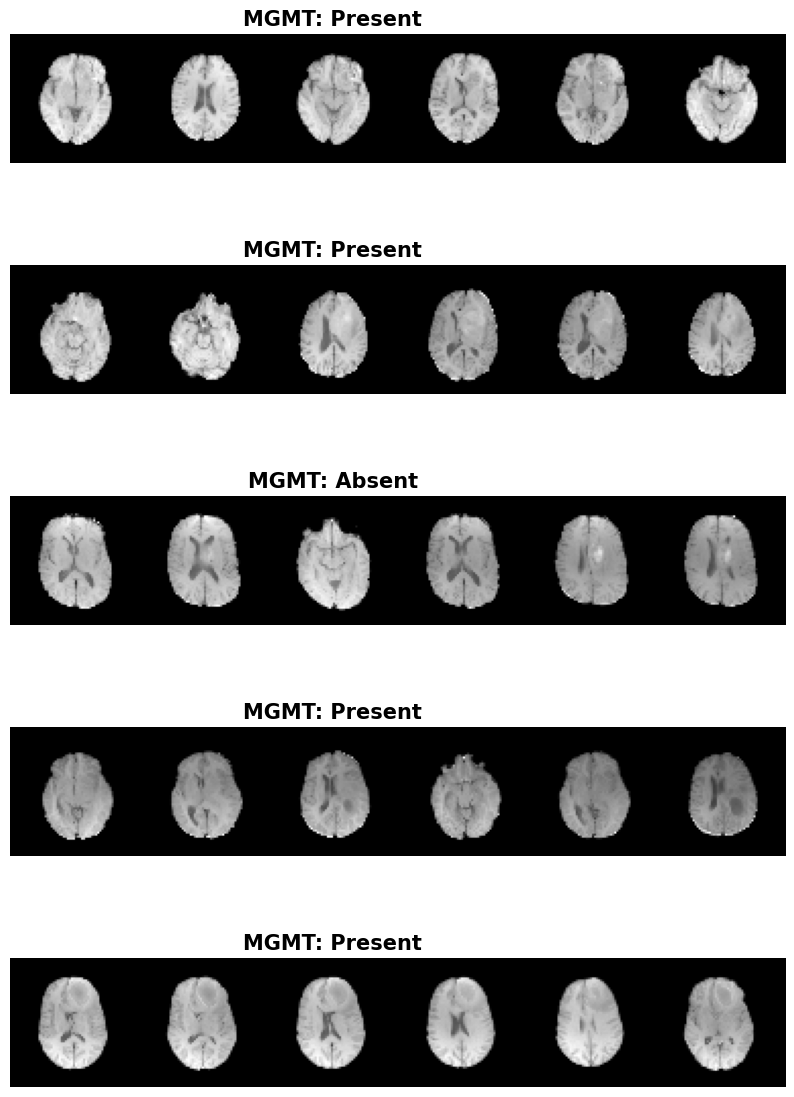

In [14]:

dataset_dir = "train"
fig, ax = plt.subplots(nrows=5, ncols=6, figsize=(10,15))
for index in range(5):
    id = train_df['BraTS21ID'][index]
    all_imgs = read_dicom_img(dataset_dir, str(id))
    ax[index][2].set_title(f"MGMT: {('Present' if train_df['MGMT_value'][index] else 'Absent')}", 
                           fontsize=15, fontweight ="bold")
    show_img(all_imgs, ax, index)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show() 
    

In [15]:
# Dataset Class
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, transform=None):
        self.dataframe = dataframe
        self.dataset_dir = dataset_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample_id = self.dataframe.iloc[idx, 0]  # Getting the BraTS21ID
        label = self.dataframe.iloc[idx, 1]      # Getting the MGMT_value

        # Read DICOM images
        sample_images = self.read_dicom_images(str(sample_id))

        # Apply transformations if specified
        if self.transform:
            sample_images = [self.transform(img) for img in sample_images]

        # Stack the images along a new dimension (sequence_len)
        sample_images = torch.stack(sample_images, dim=0)

        # Ensure the shape is (sequence_len, channels, IMG_SIZE, IMG_SIZE)
        sample_images = sample_images.unsqueeze(1)  # Add channel dimension if not present
        
        return sample_images, label

    def read_dicom_images(self, sample_id):
        file_path = os.path.join(main_path, self.dataset_dir, sample_id.zfill(5))
        final_img = []
        for mri_type in mp_mri_type:
            final_file_path = os.path.join(file_path, mri_type)
            sorted_files = sorted(os.listdir(final_file_path))

            for i in range(len(sorted_files)):
                data = pdcm.dcmread(os.path.join(final_file_path, sorted_files[i]))
                img_data = data.pixel_array
                img_data = cv2.resize(img_data, (IMG_SIZE, IMG_SIZE))
                img_data = (img_data - np.min(img_data)) / (np.max(img_data) + 1)
                final_img.append(img_data)

        final_img = sorted(final_img, key=lambda x: np.mean(x), reverse=True)[:NUM_SAMPLES]

        return final_img

In [16]:
import torch.nn as nn
import torch.nn.functional as F

# Model Definition
class TD_CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, hidden_size, num_layers):
        super(TD_CNN_LSTM_Model, self).__init__()
        # Define convolutional layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Calculate the size of the features after the convolutions and pooling
        conv_size = IMG_SIZE // 4  # This assumes 2 pooling layers

        # Define LSTM layers
        self.lstm = nn.LSTM(input_size=32 * conv_size * conv_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # Define output layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Remove the extra dimension (if channels == 1)
        x = x.squeeze(2)  # This squeezes out the third dimension if it's size 1
        # x should have the shape (batch_size, sequence_len, channels, IMG_SIZE, IMG_SIZE)
        batch_size, sequence_len, c, h, w = x.size()


        # CNN block
        x = x.view(batch_size * sequence_len, c, h, w)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten the output from CNN for LSTM
        conv_size = h // 4  # Adjust based on the number of max-pooling layers
        x = x.view(batch_size, sequence_len, -1)

        # LSTM block
        x, _ = self.lstm(x)

        # Output layer
        x = self.fc(x[:, -1, :])

        return x.squeeze(1)

In [17]:
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import Compose, ToTensor

# Assuming you have defined the BrainTumorDataset class and loaded the dataset
# Define transformations
transform = Compose([ToTensor()])  # You can add more transforms as needed

# Load the dataset
train_df = pd.read_csv(f"{main_path}/train_labels.csv")
dataset = BrainTumorDataset(train_df, dataset_dir="train", transform=transform)

# Split dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Define batch size
batch_size = 64

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [18]:
# Assuming 'data_loader' is your PyTorch DataLoader instance
number_of_train_batches = len(train_loader)
print(f"Number of train batches: {number_of_train_batches}")
number_of_test_batches = len(test_loader)
print(f"Number of test batches: {number_of_test_batches}")

Number of train batches: 8
Number of test batches: 2


In [19]:
# Check the shape of a single data sample
sample_data, _ = next(iter(train_loader))
print(sample_data.shape)

torch.Size([64, 64, 1, 1, 64, 64])


In [20]:
import os
import cv2
import numpy as np
import pandas as pd
import pydicom as pdcm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import Compose, ToTensor
from sklearn.metrics import accuracy_score, classification_report

# Define hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 0.001
num_epochs = 10
input_channels = 1  # Number of channels in each image
hidden_size = 64  # Example hidden size (adjust based on your needs)
num_layers = 2  # Example number of LSTM layers (adjust based on your needs)

# Initialize the model, loss function, and optimizer
model = TD_CNN_LSTM_Model(input_channels, hidden_size, num_layers).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Check the first batch of labels
first_batch_labels = next(iter(train_loader))[1]
print(f"First batch labels: {first_batch_labels}")
print(f"First batch labels shape: {first_batch_labels.shape}")

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to train mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Ensure inputs and labels are float32
        inputs = inputs.float()
        labels = labels.float()
        
        # Print the shape of the inputs to debug
        print(f"Inputs shape: {inputs.shape}")

        # Forward pass
        outputs = model(inputs)

        # If the model's output is 2D (e.g., [batch_size, 1]), ensure labels are also 2D
        if outputs.dim() > 1 and outputs.shape[1] == 1:
            labels = labels.view(-1, 1)
        
        # Debug print statements to check the shapes of outputs and labels
        print(f"Outputs shape: {outputs.shape}")
        print(f"Labels shape: {labels.shape}")

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update running loss and calculate accuracy
        running_loss += loss.item() * inputs.size(0)
        predictions = (outputs > 0.5).float()
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Training finished!")

# Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
y_true = []
y_pred = []

for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    # Ensure inputs are float32
    inputs = inputs.float()

    # Forward pass
    outputs = model(inputs)

    # Calculate accuracy
    predictions = (outputs > 0.5).float()

    # Collect true and predicted labels for classification report
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Absent", "Present"]))


First batch labels: tensor([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0])
First batch labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])
Outputs shape: torch.Size([64])
Labels shape: torch.Size([64])
Inputs shape: torch.Size([64, 64, 1, 1, 64, 64])

In [21]:
x.view(expected_batch_size, expected_sequence_length, channels, IMG_SIZE, IMG_SIZE)

NameError: name 'x' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import Compose, ToTensor
import numpy as np
import pandas as pd
import pydicom as pdcm
import os
import cv2
from sklearn.metrics import accuracy_score, classification_report

# Define the TD-CNN-LSTM model
class TD_CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, hidden_size, num_layers):
        super(TD_CNN_LSTM_Model, self).__init__()
        # Define convolutional layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Adjust kernel and stride as needed
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
        
        # Define LSTM layers
        self.lstm = nn.LSTM(input_size=32 * 7 * 7,  # Adjust based on the output size of conv2
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        
        # Define output layer
        self.fc = nn.Linear(hidden_size, 1)  # Output for binary classification (tumor/no tumor)
        
    def forward(self, x):
        batch_size, sequence_len, c, h, w = x.size()
        
        # CNN block
        x = x.view(batch_size * sequence_len, c, h, w)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        # Flatten the output from CNN for LSTM
        x = x.view(batch_size, sequence_len, -1)
        
        # LSTM block
        x, _ = self.lstm(x)  # Extract only the hidden state (outputs, (hidden_state, cell_state))
        
        # Output layer
        x = self.fc(x[:, -1, :])  # Use the last hidden state for classification
        
        return x.squeeze(1)

# Define the dataset class
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, transform=None):
        self.dataframe = dataframe
        self.dataset_dir = dataset_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample_id = self.dataframe.iloc[idx, 0]  # Getting the BraTS21ID
        label = self.dataframe.iloc[idx, 1]      # Getting the MGMT_value

        # Read DICOM images
        sample_images = self.read_dicom_images(str(sample_id))

        # Apply transformations if specified
        if self.transform:
            sample_images = [self.transform(img) for img in sample_images]

        # Stack the images along the channel dimension
        sample_images = torch.stack(sample_images)

        # Ensure the shape is (num_images, 1, IMG_SIZE, IMG_SIZE)
        sample_images = sample_images.unsqueeze(1)  # Add channel dimension

        return sample_images, label

    def read_dicom_images(self, sample_id):
        file_path = os.path.join(main_path, self.dataset_dir, sample_id.zfill(5))
        final_img = []
        for mri_type in mp_mri_type:
            final_file_path = os.path.join(file_path, mri_type)
            sorted_files = sorted(os.listdir(final_file_path))

            for i in range(len(sorted_files)):
                data = pdcm.dcmread(os.path.join(final_file_path, sorted_files[i]))
                img_data = data.pixel_array
                img_data = cv2.resize(img_data, (IMG_SIZE, IMG_SIZE))
                img_data = (img_data - np.min(img_data)) / (np.max(img_data) + 1)
                final_img.append(img_data)

        final_img = sorted(final_img, key=lambda x: np.mean(x), reverse=True)[:NUM_SAMPLES]

        return final_img

# Define transformations
transform = Compose([ToTensor()])  # You can add more transforms as needed

# Load the dataset
dataset = BrainTumorDataset(train_df, dataset_dir="train", transform=transform)

# Split dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Define batch size
batch_size = 64

# Create data loaders with specified batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check the shape of a single data sample
sample_data, _ = next(iter(train_loader))
print(sample_data.shape)

# Define hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 0.001
num_epochs = 10
input_channels = 1  # Number of channels in each image
hidden_size = 64  # Example hidden size (adjust based on your needs)
num_layers = 2  # Example number of LSTM layers (adjust based on your needs)

# Initialize the model, loss function, and optimizer
model = TD_CNN_LSTM_Model(input_channels, hidden_size, num_layers).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to train mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Print the shape of the inputs to debug
        print(f"Inputs shape before view: {inputs.shape}")

        # Ensure inputs are float32
        inputs = inputs.float()

        # Forward pass
        outputs = model(inputs)

        # Adjust the target tensor to match the shape of the output tensor
        labels = labels.float().unsqueeze(1)

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs > 0.5).float()
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        # Update running loss
        running_loss += loss.item() * inputs.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Training finished!")

# Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
y_true = []
y_pred = []

for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    # Ensure inputs are float32
    inputs = inputs.float()

    # Forward pass
    outputs = model(inputs)

    # Calculate accuracy
    predictions = (outputs > 0.5).float()

    # Collect true and predicted labels for classification report
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Absent", "Present"]))

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import pydicom as pdcm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import Compose, ToTensor
from sklearn.metrics import accuracy_score, classification_report

# Constants
IMG_SIZE = 64
NUM_SAMPLES = 64
mp_mri_type = ["FLAIR", "T1w", "T1wCE", "T2w"]
main_path = '/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification'

# Dataset Class
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, transform=None):
        self.dataframe = dataframe
        self.dataset_dir = dataset_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample_id = self.dataframe.iloc[idx, 0]  # Getting the BraTS21ID
        label = self.dataframe.iloc[idx, 1]      # Getting the MGMT_value

        # Read DICOM images
        sample_images = self.read_dicom_images(str(sample_id))

        # Apply transformations if specified
        if self.transform:
            sample_images = [self.transform(img) for img in sample_images]

        # Stack the images along a new dimension (sequence_len)
        sample_images = torch.stack(sample_images, dim=0)

        # Ensure the shape is (sequence_len, channels, IMG_SIZE, IMG_SIZE)
        sample_images = sample_images.unsqueeze(1)  # Add channel dimension if not present
        
        return sample_images, label

    def read_dicom_images(self, sample_id):
        file_path = os.path.join(main_path, self.dataset_dir, sample_id.zfill(5))
        final_img = []
        for mri_type in mp_mri_type:
            final_file_path = os.path.join(file_path, mri_type)
            sorted_files = sorted(os.listdir(final_file_path))

            for i in range(len(sorted_files)):
                data = pdcm.dcmread(os.path.join(final_file_path, sorted_files[i]))
                img_data = data.pixel_array
                img_data = cv2.resize(img_data, (IMG_SIZE, IMG_SIZE))
                img_data = (img_data - np.min(img_data)) / (np.max(img_data) + 1)
                final_img.append(img_data)

        final_img = sorted(final_img, key=lambda x: np.mean(x), reverse=True)[:NUM_SAMPLES]

        return final_img

# Define transformations
transform = Compose([ToTensor()])  # You can add more transforms as needed

# Load the dataset
train_df = pd.read_csv(f"{main_path}/train_labels.csv")
dataset = BrainTumorDataset(train_df, dataset_dir="train", transform=transform)

# Split dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Define batch size
batch_size = 64

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Model Definition
class TD_CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, hidden_size, num_layers):
        super(TD_CNN_LSTM_Model, self).__init__()
        # Define convolutional layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Calculate the size of the features after the convolutions and pooling
        conv_size = IMG_SIZE // 4  # This assumes 2 pooling layers

        # Define LSTM layers
        self.lstm = nn.LSTM(input_size=32 * conv_size * conv_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # Define output layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x should have the shape (batch_size, sequence_len, channels, IMG_SIZE, IMG_SIZE)
        batch_size, sequence_len, c, h, w = x.size()


        # CNN block
        x = x.view(batch_size * sequence_len, c, h, w)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten the output from CNN for LSTM
        x = x.view(batch_size, sequence_len, -1)

        # LSTM block
        x, _ = self.lstm(x)

        # Output layer
        x = self.fc(x[:, -1, :])

        return x.squeeze(1)

# Define hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 0.001
num_epochs = 10
input_channels = 1  # Number of channels in each image
hidden_size = 64  # Example hidden size (adjust based on your needs)
num_layers = 2  # Example number of LSTM layers (adjust based on your needs)

# Initialize the model, loss function, and optimizer
model = TD_CNN_LSTM_Model(input_channels, hidden_size, num_layers).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Check the first batch of labels
first_batch_labels = next(iter(train_loader))[1]
print(f"First batch labels: {first_batch_labels}")
print(f"First batch labels shape: {first_batch_labels.shape}")

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to train mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Ensure inputs and labels are float32
        inputs = inputs.float()
        labels = labels.float()
        
        # Print the shape of the inputs to debug
        print(f"Inputs shape: {inputs.shape}")

        # Forward pass
        outputs = model(inputs)

        # If the model's output is 2D (e.g., [batch_size, 1]), ensure labels are also 2D
        if outputs.dim() > 1 and outputs.shape[1] == 1:
            labels = labels.view(-1, 1)
        
        # Debug print statements to check the shapes of outputs and labels
        print(f"Outputs shape: {outputs.shape}")
        print(f"Labels shape: {labels.shape}")

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update running loss and calculate accuracy
        running_loss += loss.item() * inputs.size(0)
        predictions = (outputs > 0.5).float()
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Training finished!")

# Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
y_true = []
y_pred = []

for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    # Ensure inputs are float32
    inputs = inputs.float()

    # Forward pass
    outputs = model(inputs)

    # Calculate accuracy
    predictions = (outputs > 0.5).float()

    # Collect true and predicted labels for classification report
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Absent", "Present"]))


In [ ]:
dicom = pydicom.read_file("../input/rsna-miccai-brain-tumor-radiogenomic-classification/train/00006/T2w/Image-125.dcm")
dicom

In [ ]:
data = dicom.pixel_array
data = data - np.min(data)
data = data / np.max(data)
data = data.astype(np.uint8)
data

In [ ]:
np.max(data)

In [ ]:
def load_dicom(path):
    dicom = pydicom.read_file(path)
    data = dicom.pixel_array
    data = data - np.min(data)
    data = data / np.max(data)
    data = (data * 255).astype(np.uint8)
    return data


def visualize_sample(
    brats21id, 
    slice_i,
    mgmt_value,
    types=("FLAIR", "T1w", "T1wCE", "T2w")
):
    plt.figure(figsize=(16, 5))
    patient_path = os.path.join(
        "../input/rsna-miccai-brain-tumor-radiogenomic-classification/train/", 
        str(brats21id).zfill(5),
    )
    for i, t in enumerate(types, 1):
        t_paths = sorted(
            glob.glob(os.path.join(patient_path, t, "*")), 
            key=lambda x: int(x[:-4].split("-")[-1]),
        )
        data = load_dicom(t_paths[int(len(t_paths) * slice_i)])
        plt.subplot(1, 4, i)
        plt.imshow(data, cmap="gray")
        plt.title(f"{t}", fontsize=16)
        plt.axis("off")

    plt.suptitle(f"MGMT_value: {mgmt_value}", fontsize=16)
    plt.show()
    
for i in range(10):
     _brats21id = train_df.iloc[i]["BraTS21ID"]
     _mgmt_value = train_df.iloc[i]["MGMT_value"]
     visualize_sample(brats21id=_brats21id, mgmt_value=_mgmt_value, slice_i=0.5)

In [ ]:
from pathlib import Path
from collections import defaultdict
mri_types_dict = defaultdict(list)
samples = glob.glob('../input/rsna-miccai-brain-tumor-radiogenomic-classification/train/*')

for sample in samples:
    for mri_t_dir in glob.glob(f'{sample}/*'):
        mri_t = mri_t_dir.split('/')[-1]
        mri_types_dict[mri_t].append(len(glob.glob(f'{mri_t_dir}/*')))

In [ ]:
mri_types_df = pd.DataFrame(data=np.array(list(mri_types_dict.values())).T, columns=mri_types_dict.keys())
mri_types_df.head()